In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

In [3]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (9712, 8)


In [5]:
print("Columns:", df.columns)

Columns: Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [7]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [8]:
df.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [9]:
df['Health_Impacts'] = df['Health_Impacts'].fillna("None")

In [10]:
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[5,10,13,16,18],
                         labels=['6-10','11-13','14-16','17-18'])

In [11]:
# Create Age Bands with meaningful names
df['Age_Band'] = pd.cut(df['Age'],
                        bins=[5,10,13,16,18],
                        labels=['Early Childhood (6-10)',
                                'Pre-Teen (11-13)',
                                'Teen (14-16)',
                                'Late Teen (17-18)'])

df[['Age','Age_Band']].head()

,Age,Age_Band
0,14,Teen (14-16)
1,11,Pre-Teen (11-13)
2,18,Late Teen (17-18)
3,15,Teen (14-16)
4,12,Pre-Teen (11-13)


In [12]:
# Create duration category
df['Duration_Category'] = pd.cut(df['Avg_Daily_Screen_Time_hr'],
                                 bins=[0,2,4,6,10],
                                 labels=['Low (0-2 hrs)',
                                         'Moderate (2-4 hrs)',
                                         'High (4-6 hrs)',
                                         'Extreme (6+ hrs)'])

df[['Avg_Daily_Screen_Time_hr','Duration_Category']].head()

,Avg_Daily_Screen_Time_hr,Duration_Category
0,3.99,Moderate (2-4 hrs)
1,4.61,High (4-6 hrs)
2,3.73,Moderate (2-4 hrs)
3,1.21,Low (0-2 hrs)
4,5.89,High (4-6 hrs)


In [13]:
# Calculate overall mean screen time
mean_screen_time = df['Avg_Daily_Screen_Time_hr'].mean()

# Create weekday/weekend flag
df['Day_Type_Flag'] = np.where(df['Avg_Daily_Screen_Time_hr'] > mean_screen_time,
                               'Weekend-like Usage',
                               'Weekday-like Usage')

df[['Avg_Daily_Screen_Time_hr','Day_Type_Flag']].head()

,Avg_Daily_Screen_Time_hr,Day_Type_Flag
0,3.99,Weekday-like Usage
1,4.61,Weekend-like Usage
2,3.73,Weekday-like Usage
3,1.21,Weekday-like Usage
4,5.89,Weekend-like Usage


In [14]:
# Device share percentage
device_share = df['Primary_Device'].value_counts(normalize=True) * 100
device_share = device_share.round(2)

device_share

Primary_Device
Smartphone    47.03
TV            25.61
Laptop        14.75
Tablet        12.60
Name: proportion, dtype: float64

In [15]:
df['Educational_to_Recreational_Ratio'].describe()

count    9712.000000
mean        0.427226
std         0.073221
min         0.300000
25%         0.370000
50%         0.430000
75%         0.480000
max         0.600000
Name: Educational_to_Recreational_Ratio, dtype: float64

In [16]:
df['Usage_Type'] = pd.cut(
    df['Educational_to_Recreational_Ratio'],
    bins=[0.30, 0.38, 0.48, 0.60],
    labels=['Highly Recreational',
            'Moderately Recreational',
            'Closer to Balanced']
)

df['Usage_Type'].value_counts()

Usage_Type
Moderately Recreational    4633
Highly Recreational        2833
Closer to Balanced         2062
Name: count, dtype: int64

In [17]:
# Calculate total screen time per device
device_time_share = df.groupby('Primary_Device')['Avg_Daily_Screen_Time_hr'].sum()

# Convert to percentage
device_time_share = (device_time_share / device_time_share.sum()) * 100
device_time_share = device_time_share.round(2)

device_time_share

Primary_Device
Laptop        15.12
Smartphone    47.42
TV            25.22
Tablet        12.24
Name: Avg_Daily_Screen_Time_hr, dtype: float64

In [18]:
# Save updated dataset with derived fields
df.to_csv("Indian_Kids_Screen_Time_Processed.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


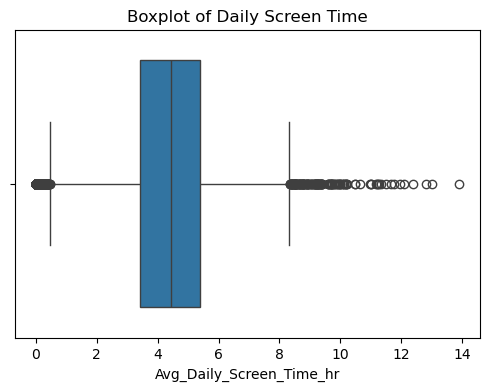

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Avg_Daily_Screen_Time_hr'])
plt.title("Boxplot of Daily Screen Time")
plt.show()

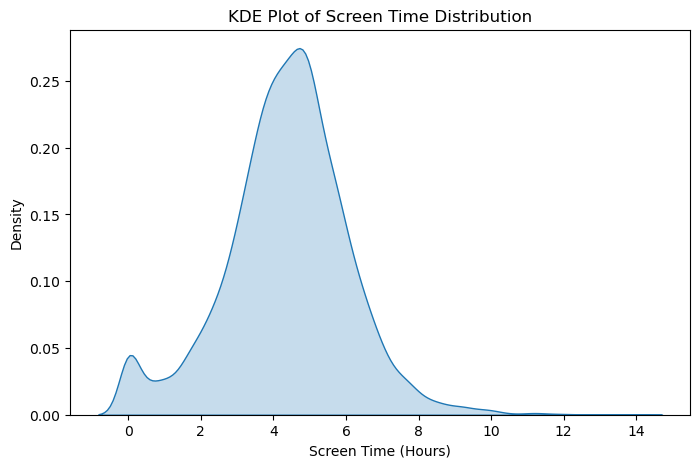

In [20]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['Avg_Daily_Screen_Time_hr'], fill=True)
plt.title("KDE Plot of Screen Time Distribution")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Density")
plt.show()

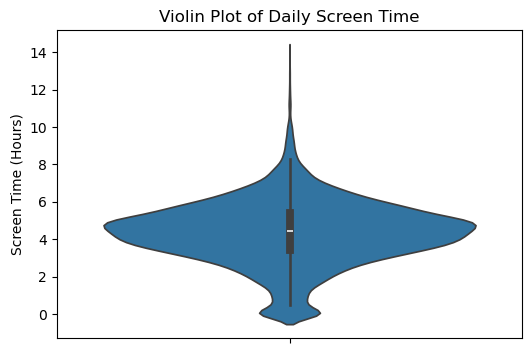

In [21]:
plt.figure(figsize=(6,4))
sns.violinplot(y=df['Avg_Daily_Screen_Time_hr'])
plt.title("Violin Plot of Daily Screen Time")
plt.ylabel("Screen Time (Hours)")
plt.show()

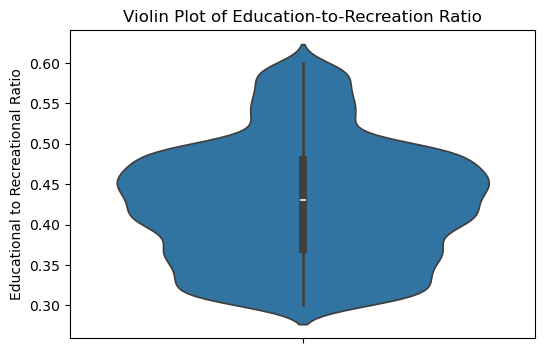

In [22]:
plt.figure(figsize=(6,4))
sns.violinplot(y=df['Educational_to_Recreational_Ratio'])
plt.title("Violin Plot of Education-to-Recreation Ratio")
plt.ylabel("Educational to Recreational Ratio")
plt.show()

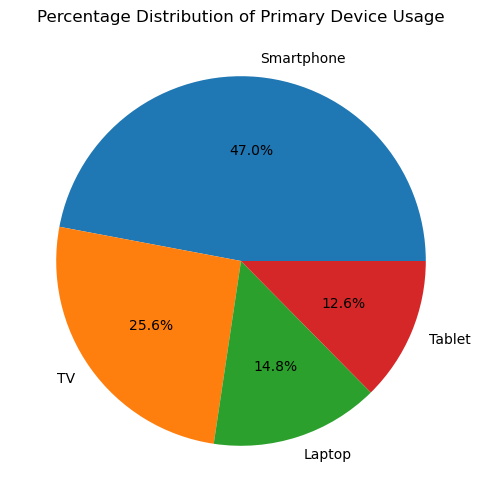

In [23]:
device_counts = df['Primary_Device'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(device_counts.values,
        labels=device_counts.index,
        autopct='%1.1f%%')
plt.title("Percentage Distribution of Primary Device Usage")
plt.show()

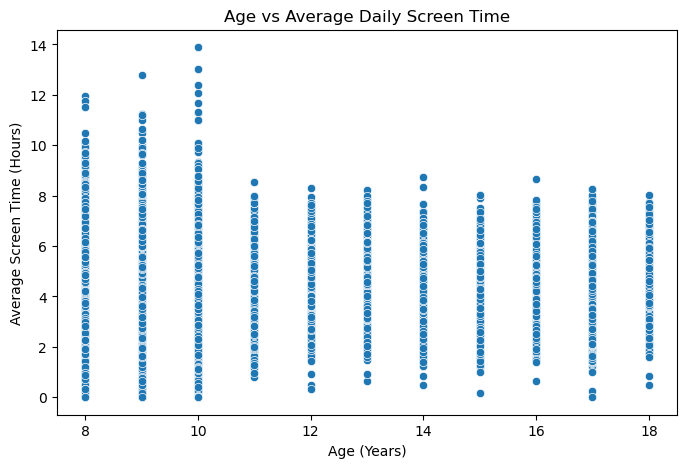

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age',
                y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Age vs Average Daily Screen Time")
plt.xlabel("Age (Years)")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

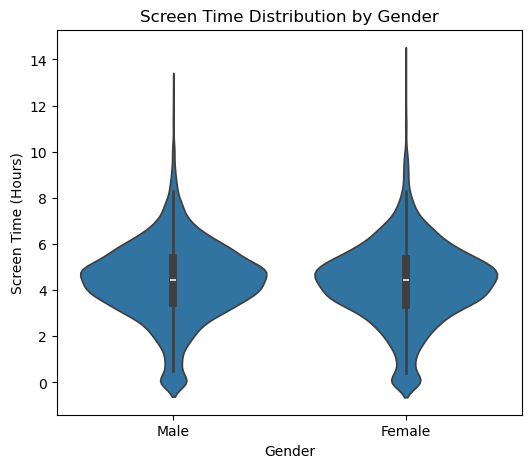

In [25]:
plt.figure(figsize=(6,5))
sns.violinplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Screen Time (Hours)")
plt.show()

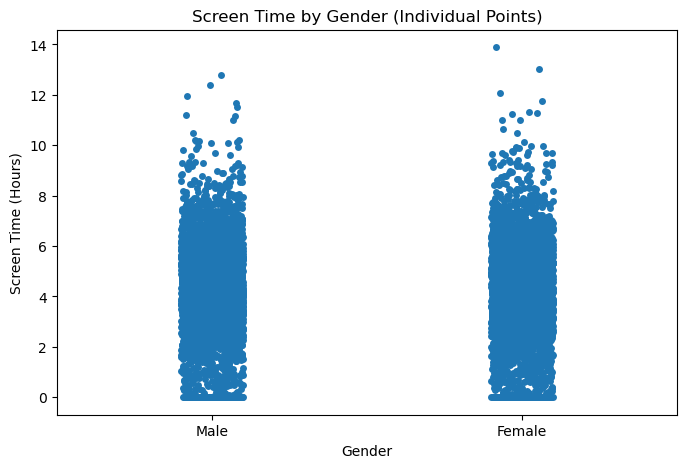

In [26]:
plt.figure(figsize=(8,5))
sns.stripplot(x='Gender',
              y='Avg_Daily_Screen_Time_hr',
              data=df)
plt.title("Screen Time by Gender (Individual Points)")
plt.xlabel("Gender")
plt.ylabel("Screen Time (Hours)")
plt.show()

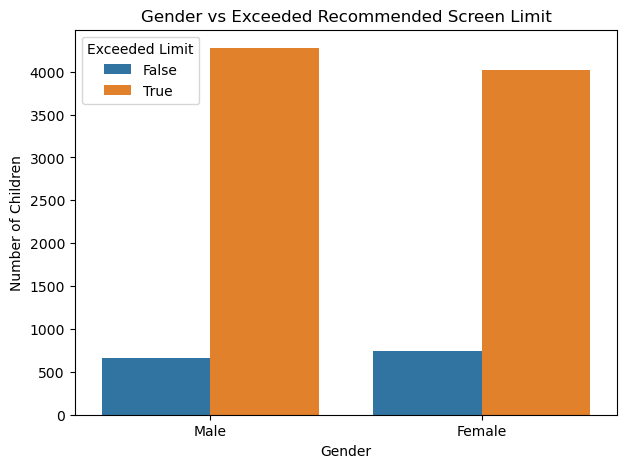

In [27]:
plt.figure(figsize=(7,5))
sns.countplot(x='Gender',
              hue='Exceeded_Recommended_Limit',
              data=df)
plt.title("Gender vs Exceeded Recommended Screen Limit")
plt.xlabel("Gender")
plt.ylabel("Number of Children")
plt.legend(title="Exceeded Limit")
plt.show()

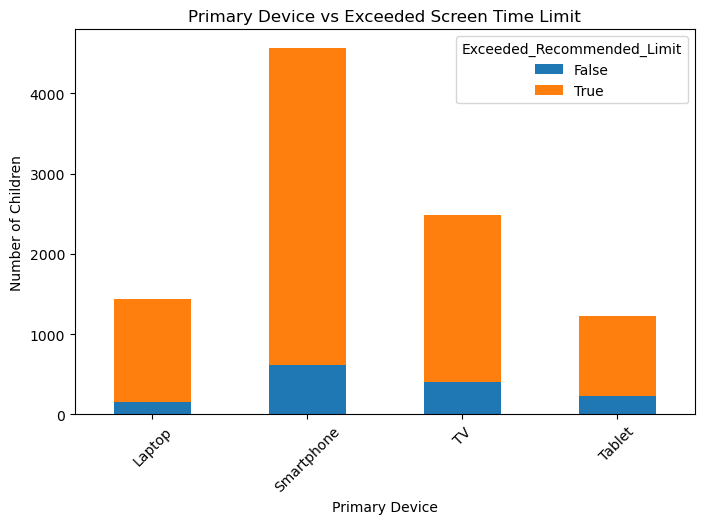

In [28]:
ct = pd.crosstab(df['Primary_Device'],
                 df['Exceeded_Recommended_Limit'])

ct.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Primary Device vs Exceeded Screen Time Limit")
plt.xlabel("Primary Device")
plt.ylabel("Number of Children")
plt.xticks(rotation=45)
plt.show()

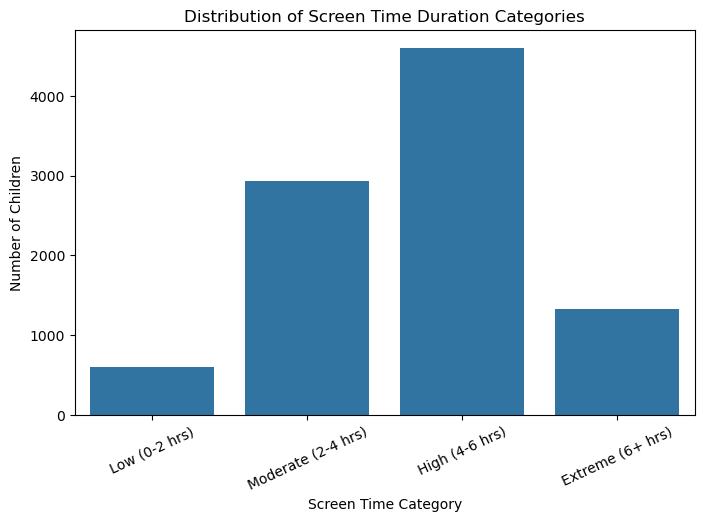

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(x='Duration_Category', data=df)
plt.title("Distribution of Screen Time Duration Categories")
plt.xlabel("Screen Time Category")
plt.ylabel("Number of Children")
plt.xticks(rotation=25)
plt.show()

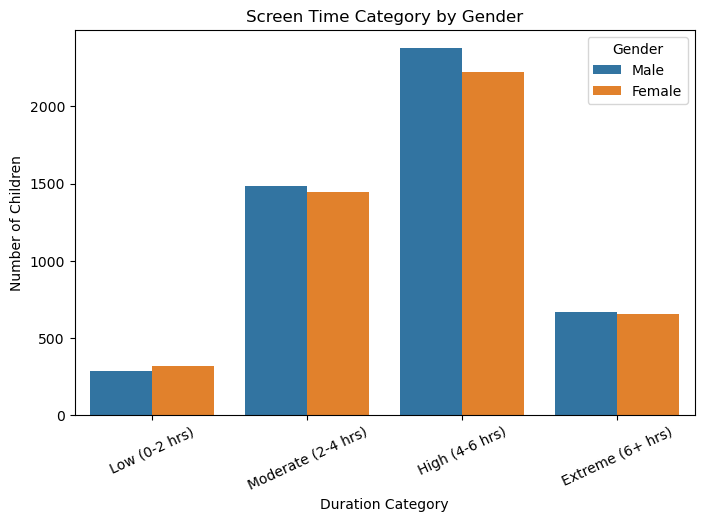

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(x='Duration_Category', hue='Gender', data=df)
plt.title("Screen Time Category by Gender")
plt.xlabel("Duration Category")
plt.ylabel("Number of Children")
plt.xticks(rotation=25)
plt.show()

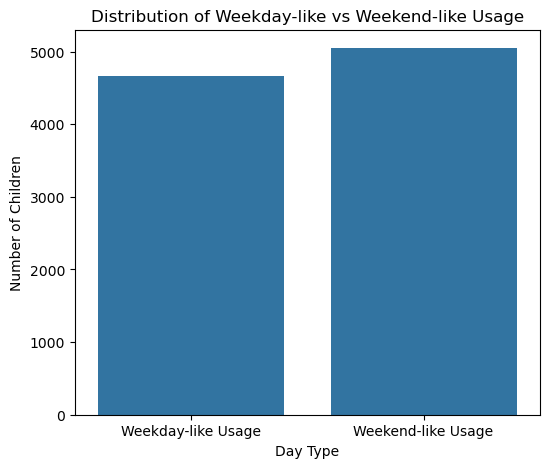

In [31]:
plt.figure(figsize=(6,5))
sns.countplot(x='Day_Type_Flag', data=df)
plt.title("Distribution of Weekday-like vs Weekend-like Usage")
plt.xlabel("Day Type")
plt.ylabel("Number of Children")
plt.show()

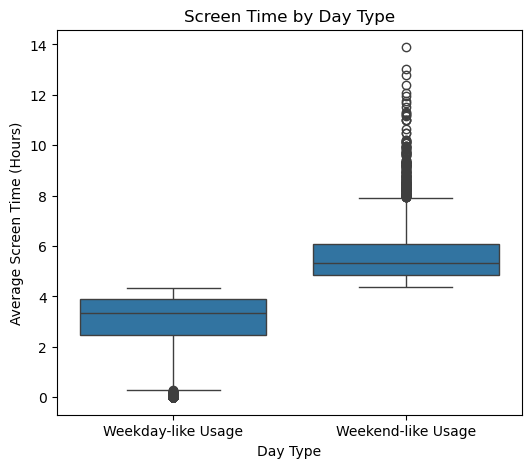

In [32]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Day_Type_Flag', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

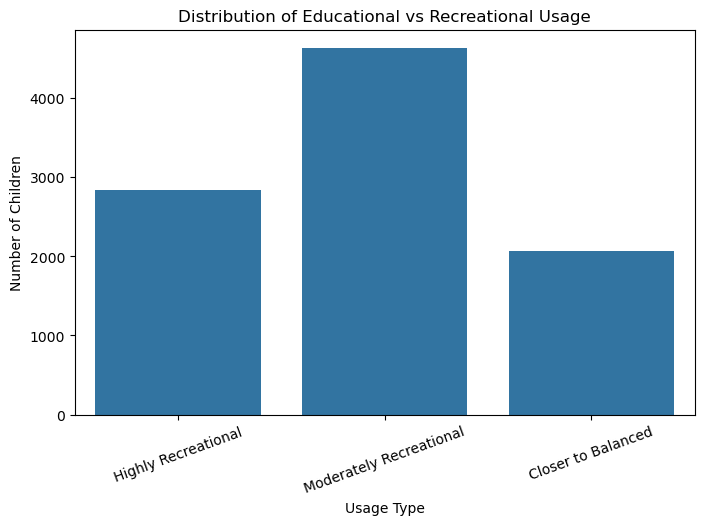

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x='Usage_Type', data=df)
plt.title("Distribution of Educational vs Recreational Usage")
plt.xlabel("Usage Type")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

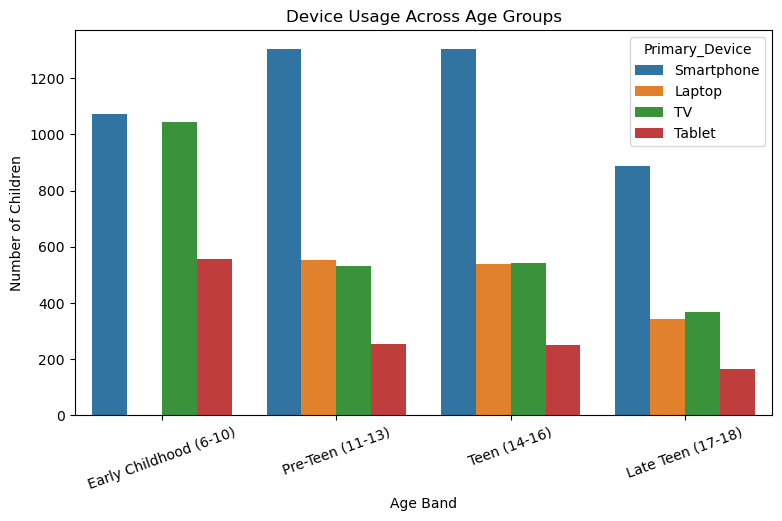

In [34]:
plt.figure(figsize=(9,5))
sns.countplot(x='Age_Band', hue='Primary_Device', data=df)
plt.title("Device Usage Across Age Groups")
plt.xlabel("Age Band")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

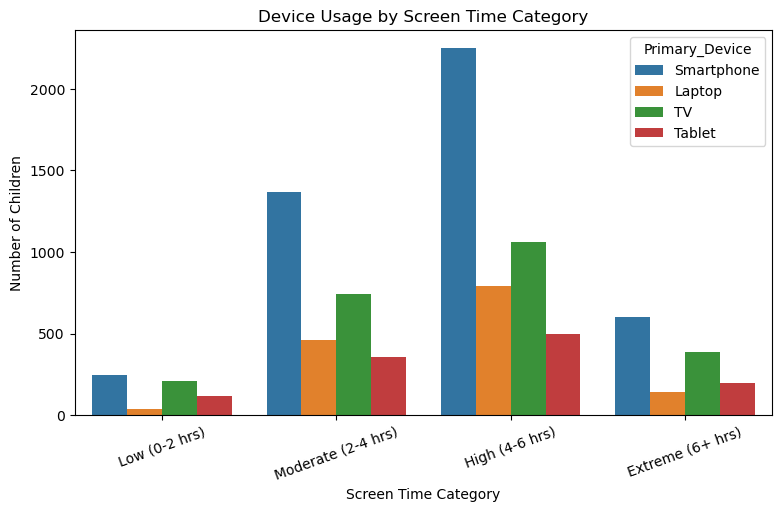

In [35]:
plt.figure(figsize=(9,5))
sns.countplot(x='Duration_Category', hue='Primary_Device', data=df)
plt.title("Device Usage by Screen Time Category")
plt.xlabel("Screen Time Category")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

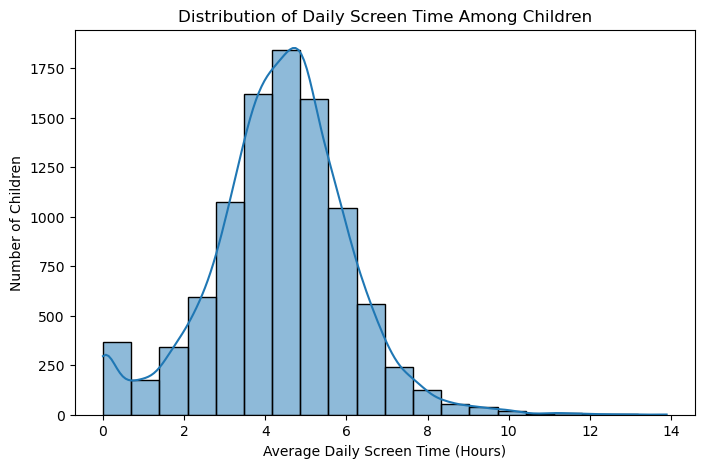

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=20, kde=True)
plt.title("Distribution of Daily Screen Time Among Children")
plt.xlabel("Average Daily Screen Time (Hours)")
plt.ylabel("Number of Children")
plt.show()

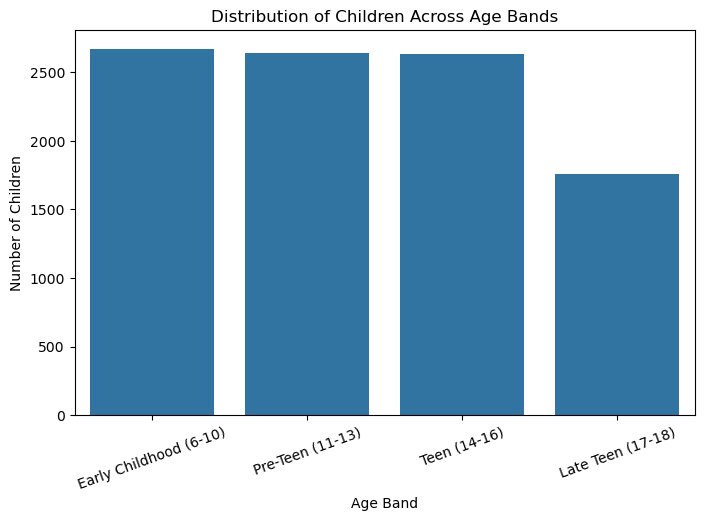

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(x='Age_Band', data=df)
plt.title("Distribution of Children Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

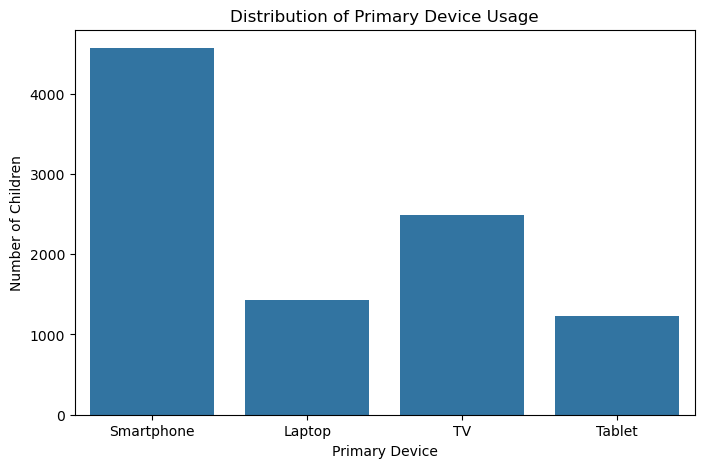

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(x='Primary_Device', data=df)
plt.title("Distribution of Primary Device Usage")
plt.xlabel("Primary Device")
plt.ylabel("Number of Children")
plt.show()

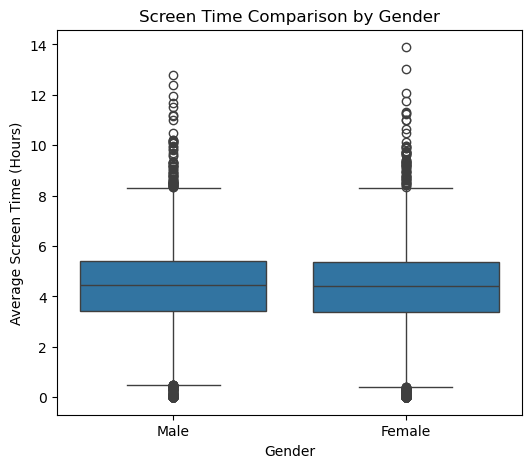

In [39]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time Comparison by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

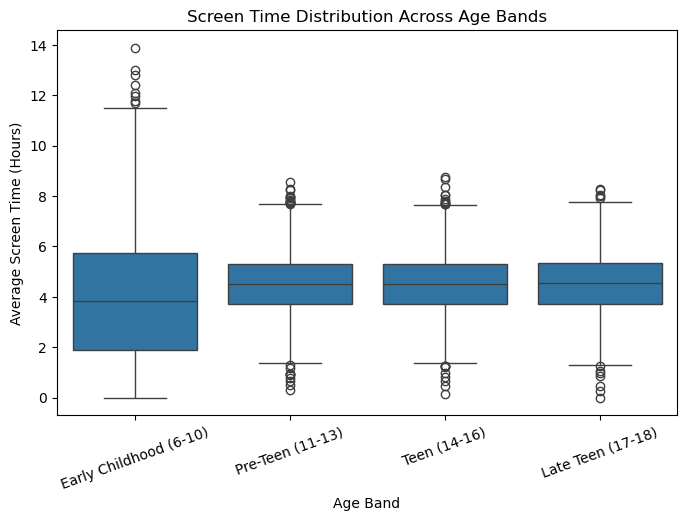

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time Distribution Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=20)
plt.show()

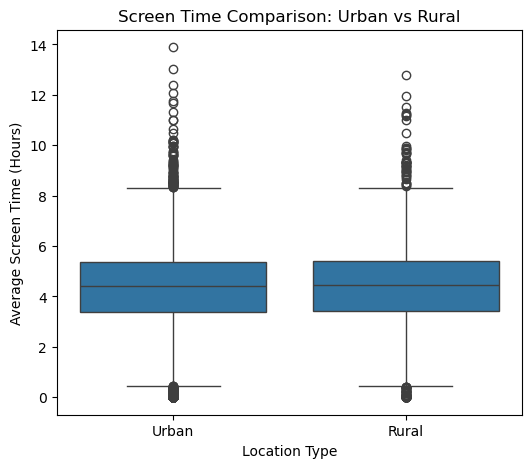

In [41]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time Comparison: Urban vs Rural")
plt.xlabel("Location Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

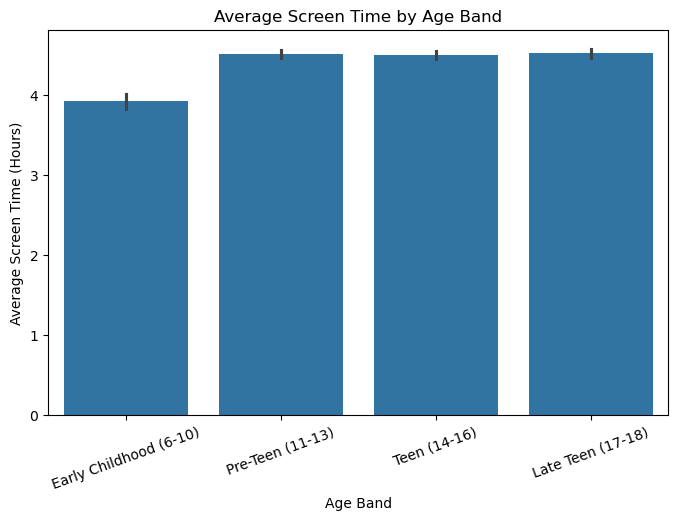

In [42]:
plt.figure(figsize=(8,5))
sns.barplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Average Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=20)
plt.show()

C:\Users\Krishba\AppData\Local\Temp\ipykernel_23220\4262527894.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_screen_avg = df.groupby('Age_Band')['Avg_Daily_Screen_Time_hr'].mean()


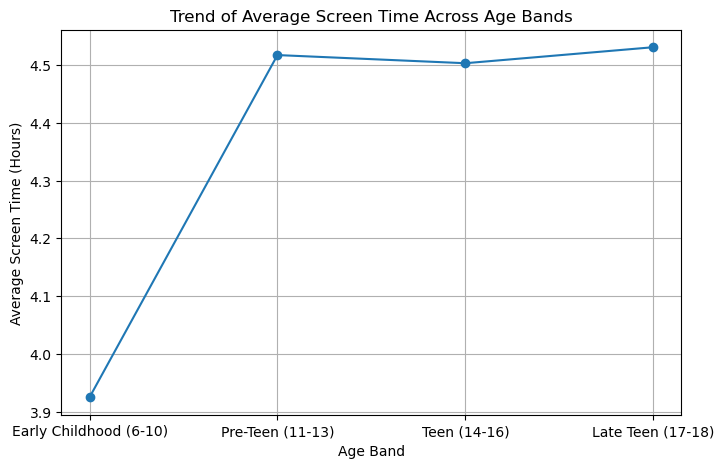

In [43]:
age_screen_avg = df.groupby('Age_Band')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(8,5))
plt.plot(age_screen_avg.index, age_screen_avg.values, marker='o')
plt.title("Trend of Average Screen Time Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.grid(True)
plt.show()

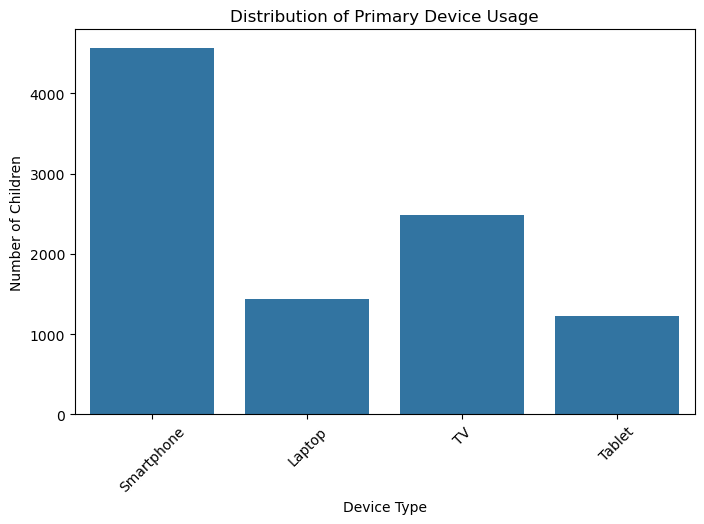

In [44]:
plt.figure(figsize=(8,5))
sns.countplot(x='Primary_Device', data=df)
plt.title("Distribution of Primary Device Usage")
plt.xlabel("Device Type")
plt.ylabel("Number of Children")
plt.xticks(rotation=45)
plt.show()

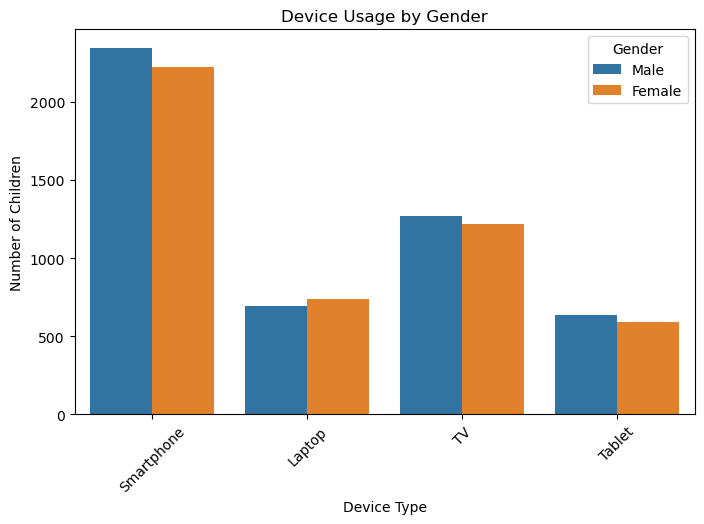

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(x='Primary_Device', hue='Gender', data=df)
plt.title("Device Usage by Gender")
plt.xlabel("Device Type")
plt.ylabel("Number of Children")
plt.xticks(rotation=45)
plt.show()

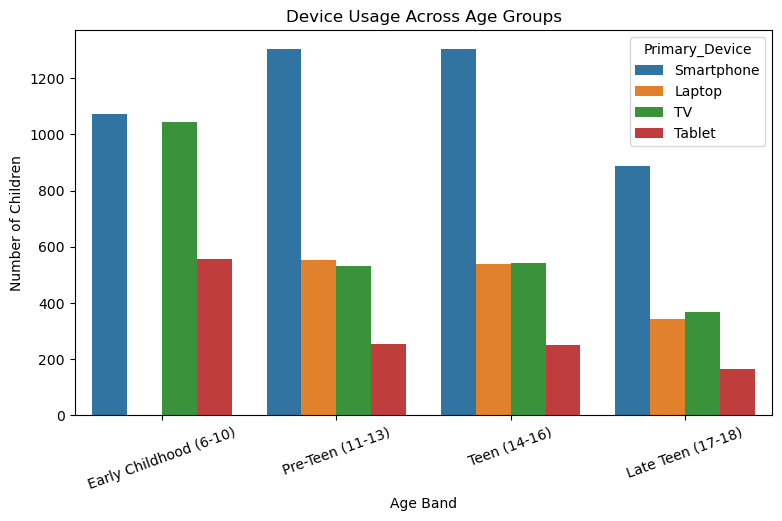

In [46]:
plt.figure(figsize=(9,5))
sns.countplot(x='Age_Band', hue='Primary_Device', data=df)
plt.title("Device Usage Across Age Groups")
plt.xlabel("Age Band")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

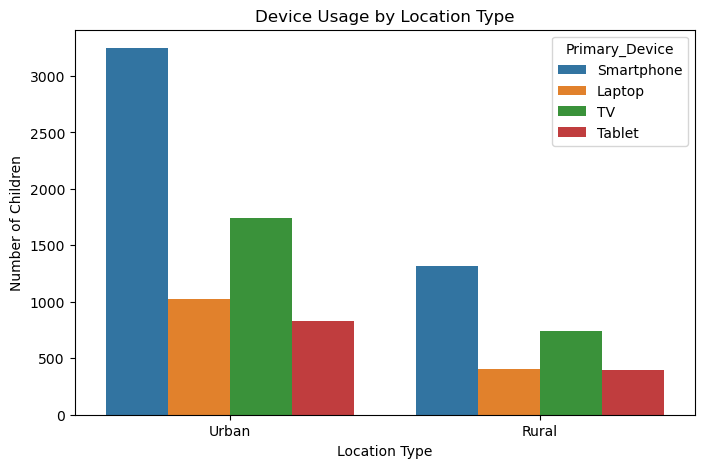

In [47]:
plt.figure(figsize=(8,5))
sns.countplot(x='Urban_or_Rural', hue='Primary_Device', data=df)
plt.title("Device Usage by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Number of Children")
plt.show()

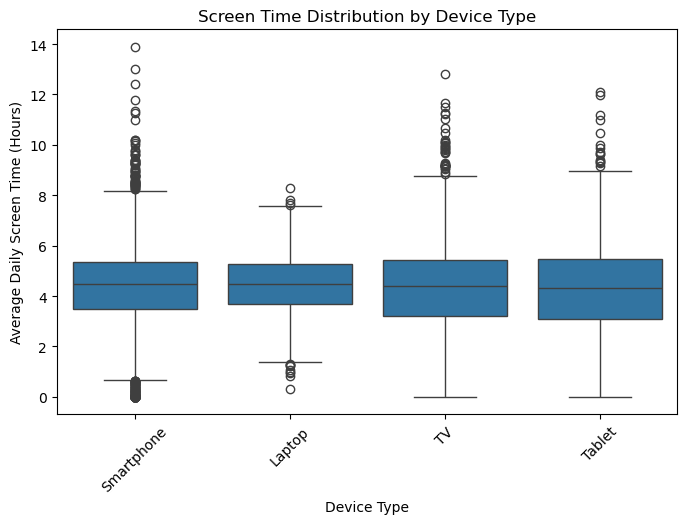

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Primary_Device', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time Distribution by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Daily Screen Time (Hours)")
plt.xticks(rotation=45)
plt.show()

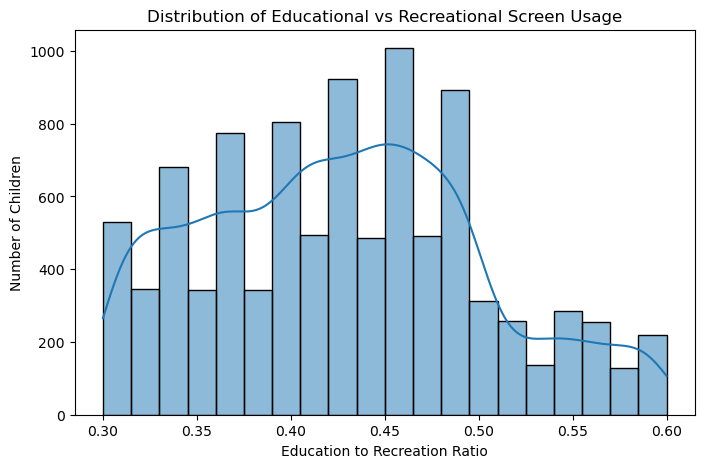

In [49]:
#week 4
plt.figure(figsize=(8,5))
sns.histplot(df['Educational_to_Recreational_Ratio'], bins=20, kde=True)
plt.title("Distribution of Educational vs Recreational Screen Usage")
plt.xlabel("Education to Recreation Ratio")
plt.ylabel("Number of Children")
plt.show()

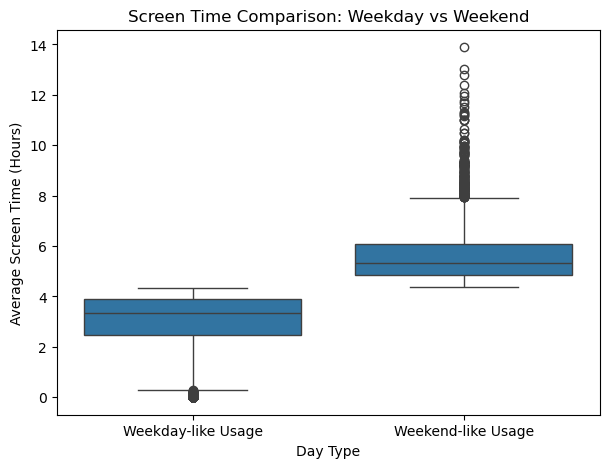

In [50]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Day_Type_Flag', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time Comparison: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

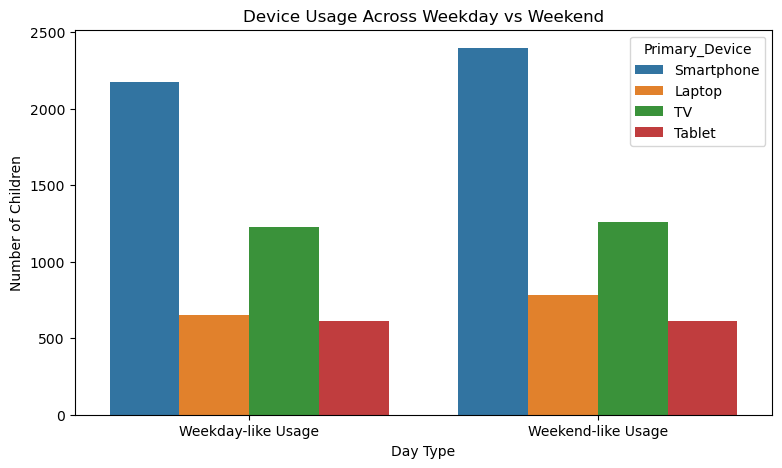

In [51]:
plt.figure(figsize=(9,5))
sns.countplot(x='Day_Type_Flag', hue='Primary_Device', data=df)
plt.title("Device Usage Across Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Number of Children")
plt.show()

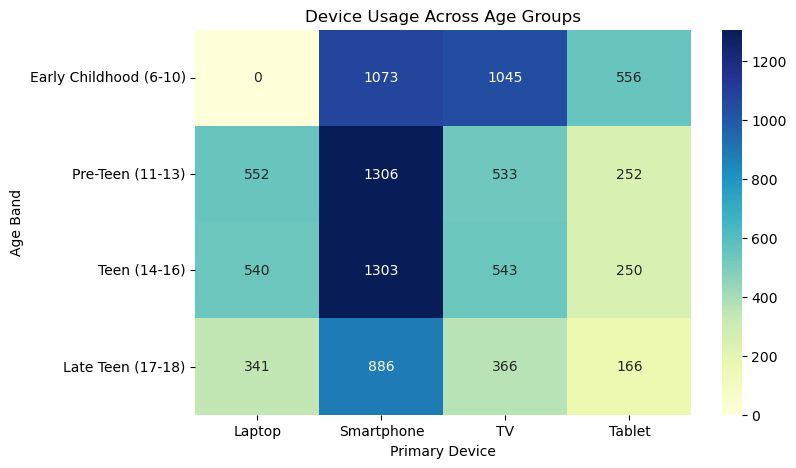

In [52]:
device_age = pd.crosstab(df['Age_Band'], df['Primary_Device'])

plt.figure(figsize=(8,5))
sns.heatmap(device_age, annot=True, cmap='YlGnBu', fmt='d')

plt.title("Device Usage Across Age Groups")
plt.xlabel("Primary Device")
plt.ylabel("Age Band")
plt.show()

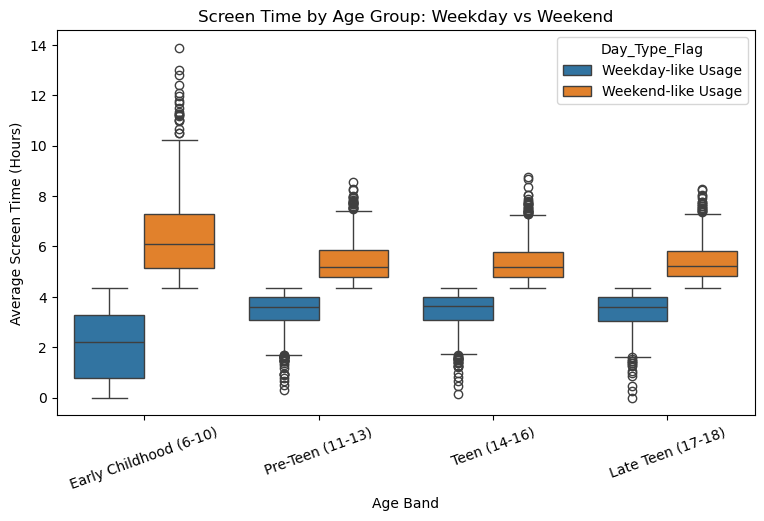

In [53]:
plt.figure(figsize=(9,5))
sns.boxplot(x='Age_Band',
            y='Avg_Daily_Screen_Time_hr',
            hue='Day_Type_Flag',
            data=df)

plt.title("Screen Time by Age Group: Weekday vs Weekend")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=20)
plt.show()

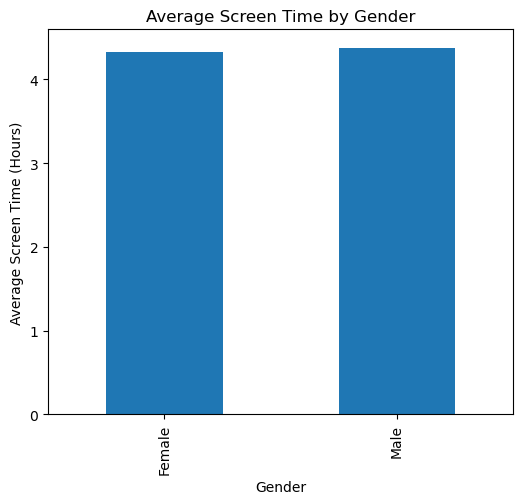

In [54]:
gender_peak = df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(6,5))
gender_peak.plot(kind='bar')

plt.title("Average Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

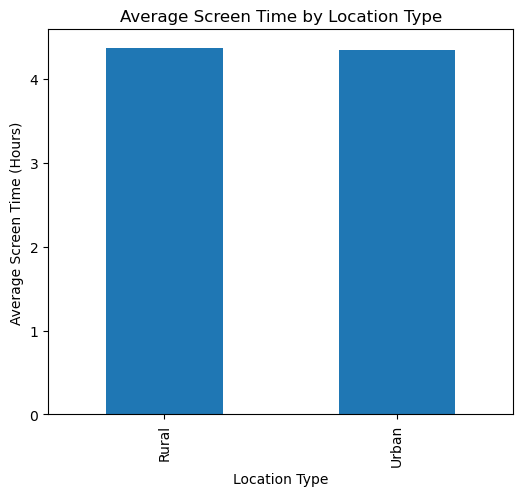

In [55]:
location_peak = df.groupby('Urban_or_Rural')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(6,5))
location_peak.plot(kind='bar')

plt.title("Average Screen Time by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

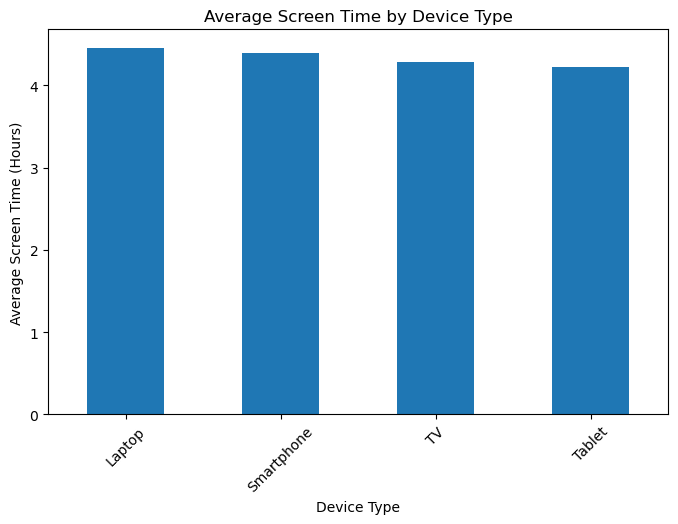

In [56]:
device_peak = df.groupby('Primary_Device')['Avg_Daily_Screen_Time_hr'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
device_peak.plot(kind='bar')

plt.title("Average Screen Time by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=45)
plt.show()

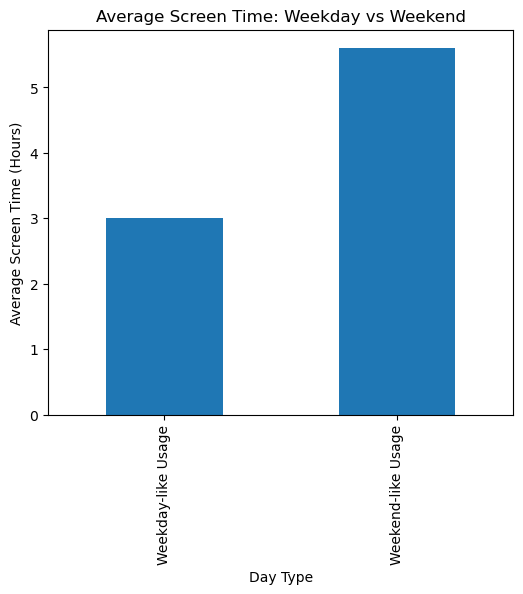

In [57]:
day_peak = df.groupby('Day_Type_Flag')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(6,5))
day_peak.plot(kind='bar')

plt.title("Average Screen Time: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

C:\Users\Krishba\AppData\Local\Temp\ipykernel_23220\3437103624.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_device_cohort = df.groupby(['Age_Band','Primary_Device'])['Avg_Daily_Screen_Time_hr'].mean().unstack()


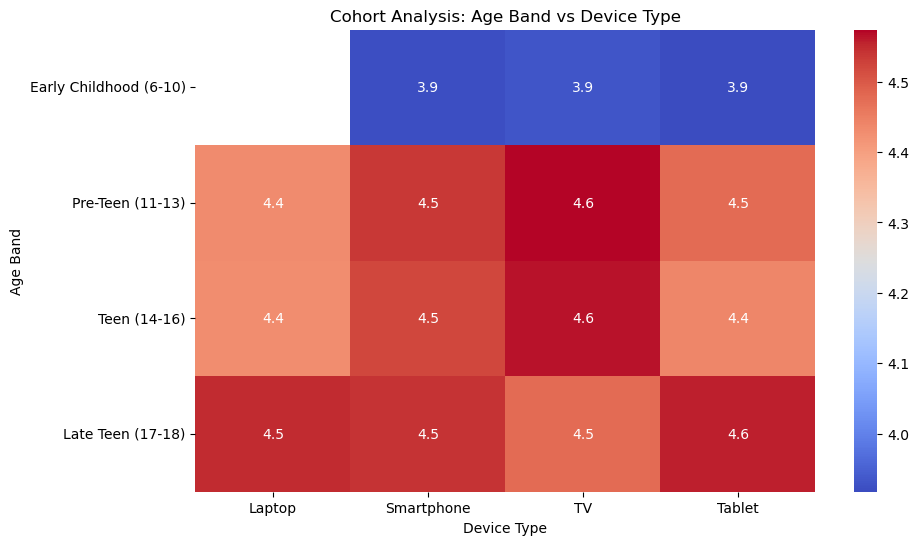

In [58]:
#week 5
age_device_cohort = df.groupby(['Age_Band','Primary_Device'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(age_device_cohort, annot=True, cmap='coolwarm')

plt.title("Cohort Analysis: Age Band vs Device Type")
plt.xlabel("Device Type")
plt.ylabel("Age Band")
plt.show()

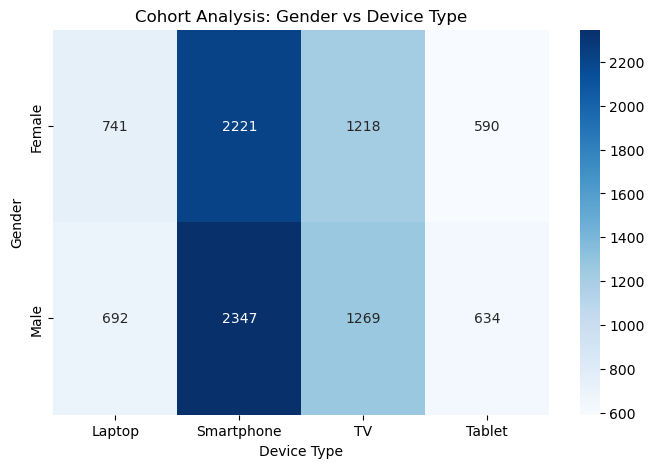

In [59]:
gender_device_cohort = pd.crosstab(df['Gender'], df['Primary_Device'])

plt.figure(figsize=(8,5))
sns.heatmap(gender_device_cohort, annot=True, cmap="Blues", fmt='d')

plt.title("Cohort Analysis: Gender vs Device Type")
plt.xlabel("Device Type")
plt.ylabel("Gender")
plt.show()

C:\Users\Krishba\AppData\Local\Temp\ipykernel_23220\2309223255.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_location_cohort = df.groupby(['Age_Band','Urban_or_Rural'])['Avg_Daily_Screen_Time_hr'].mean().unstack()


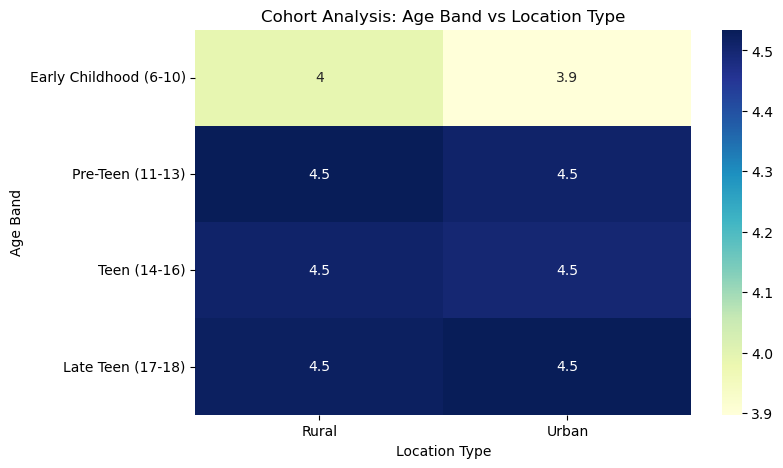

In [60]:
age_location_cohort = df.groupby(['Age_Band','Urban_or_Rural'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(8,5))
sns.heatmap(age_location_cohort, annot=True, cmap='YlGnBu')

plt.title("Cohort Analysis: Age Band vs Location Type")
plt.xlabel("Location Type")
plt.ylabel("Age Band")
plt.show()

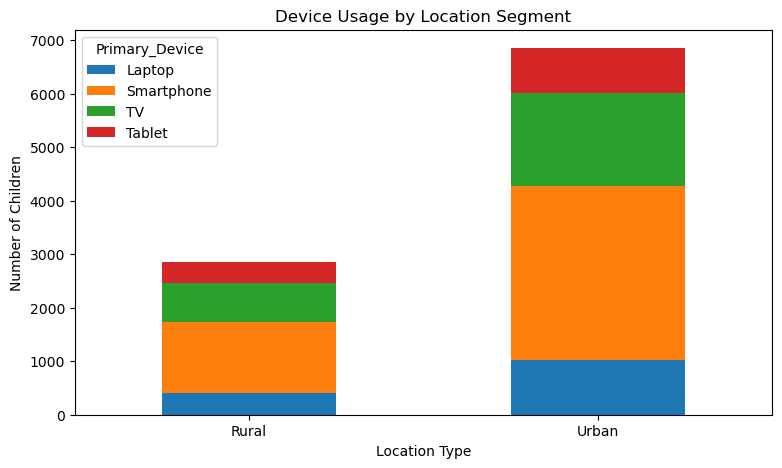

In [61]:
location_device_segment = pd.crosstab(df['Urban_or_Rural'], df['Primary_Device'])

location_device_segment.plot(kind='bar', stacked=True, figsize=(9,5))

plt.title("Device Usage by Location Segment")
plt.xlabel("Location Type")
plt.ylabel("Number of Children")
plt.xticks(rotation=0)
plt.show()

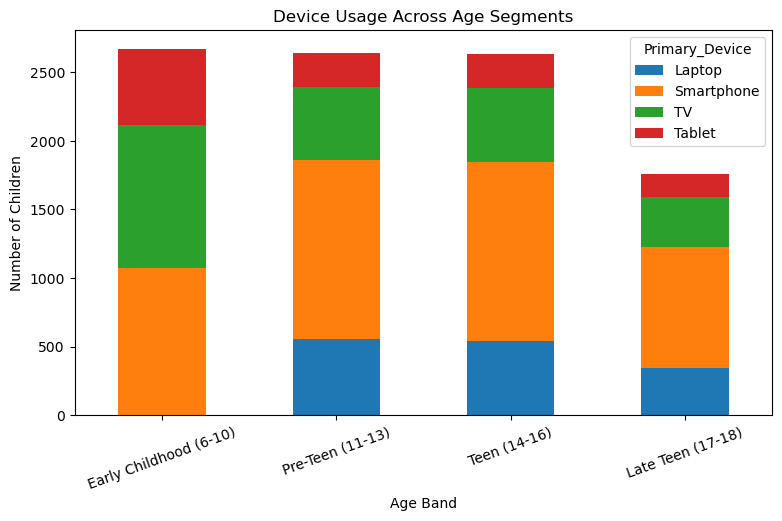

In [62]:
age_device_segment = pd.crosstab(df['Age_Band'], df['Primary_Device'])

age_device_segment.plot(kind='bar', stacked=True, figsize=(9,5))

plt.title("Device Usage Across Age Segments")
plt.xlabel("Age Band")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

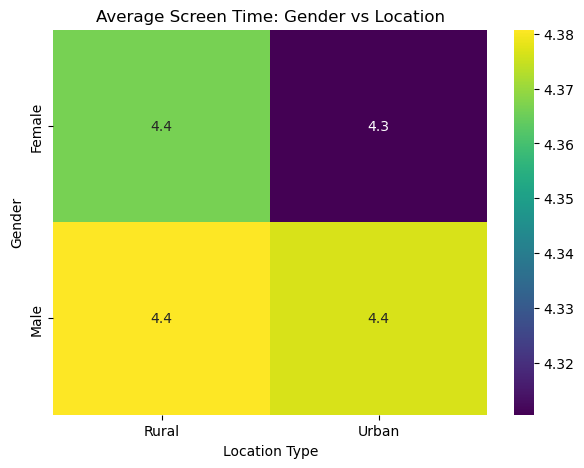

In [63]:
gender_location_cohort = df.groupby(['Gender','Urban_or_Rural'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(7,5))
sns.heatmap(gender_location_cohort, annot=True, cmap="viridis")

plt.title("Average Screen Time: Gender vs Location")
plt.xlabel("Location Type")
plt.ylabel("Gender")
plt.show()

C:\Users\Krishba\AppData\Local\Temp\ipykernel_23220\3005450242.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_day_segment = df.groupby(['Age_Band','Day_Type_Flag'])['Avg_Daily_Screen_Time_hr'].mean().unstack()


<Figure size 900x500 with 0 Axes>

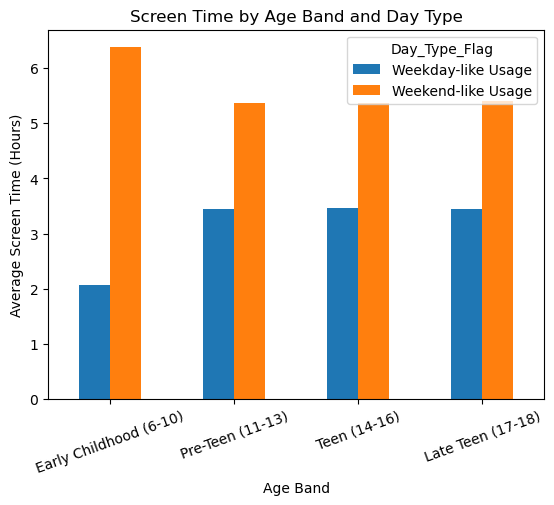

In [64]:
age_day_segment = df.groupby(['Age_Band','Day_Type_Flag'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(9,5))
age_day_segment.plot(kind='bar')

plt.title("Screen Time by Age Band and Day Type")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=20)
plt.show()

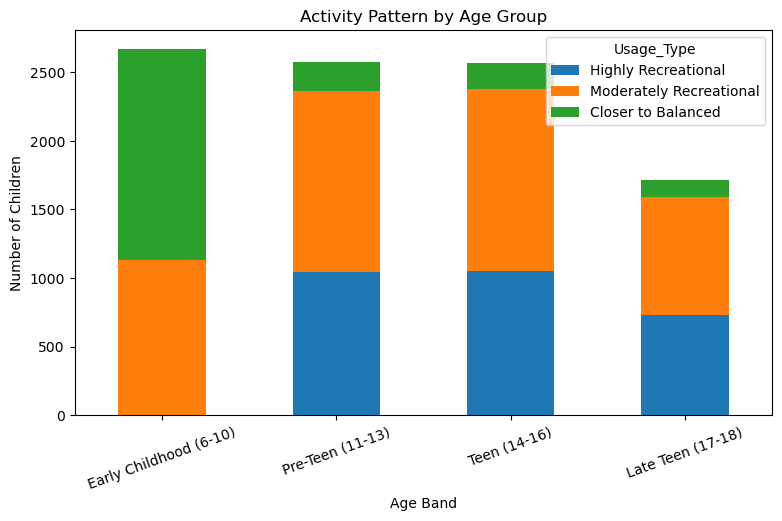

In [65]:
activity_cohort = pd.crosstab(df['Age_Band'], df['Usage_Type'])

activity_cohort.plot(kind='bar', stacked=True, figsize=(9,5))

plt.title("Activity Pattern by Age Group")
plt.xlabel("Age Band")
plt.ylabel("Number of Children")
plt.xticks(rotation=20)
plt.show()

C:\Users\Krishba\AppData\Local\Temp\ipykernel_23220\1697278600.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_day_habit = df.groupby(['Age_Band','Day_Type_Flag'])['Avg_Daily_Screen_Time_hr'].mean().unstack()


<Figure size 900x500 with 0 Axes>

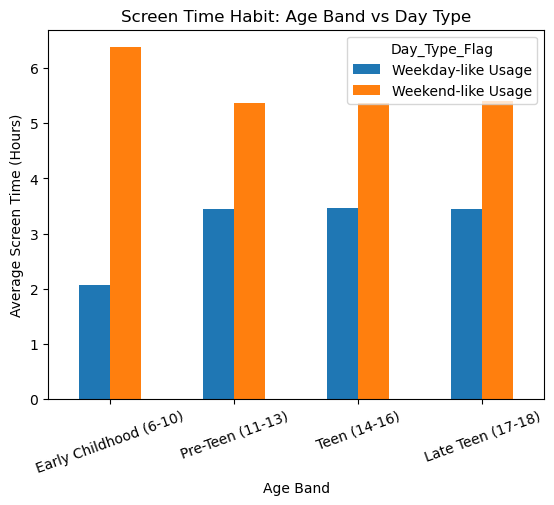

In [66]:
age_day_habit = df.groupby(['Age_Band','Day_Type_Flag'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(9,5))
age_day_habit.plot(kind='bar')

plt.title("Screen Time Habit: Age Band vs Day Type")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.xticks(rotation=20)
plt.show()

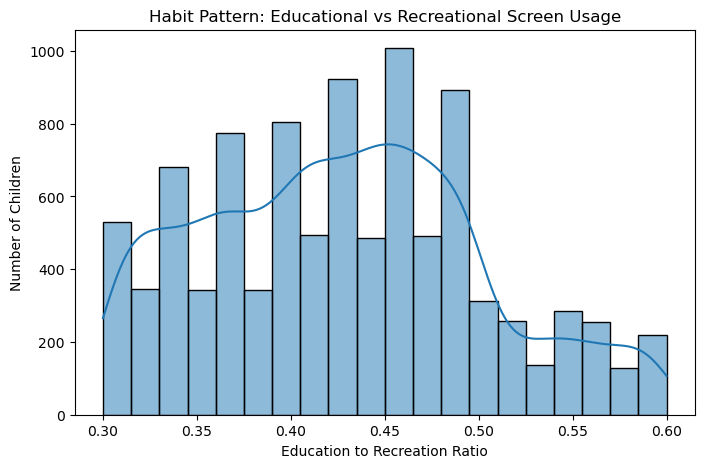

In [67]:
plt.figure(figsize=(8,5))
sns.histplot(df['Educational_to_Recreational_Ratio'], bins=20, kde=True)

plt.title("Habit Pattern: Educational vs Recreational Screen Usage")
plt.xlabel("Education to Recreation Ratio")
plt.ylabel("Number of Children")
plt.show()

C:\Users\Krishba\AppData\Local\Temp\ipykernel_23220\2418875233.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_pattern = df.groupby(['Age_Band','Primary_Device'])['Avg_Daily_Screen_Time_hr'].mean().unstack()


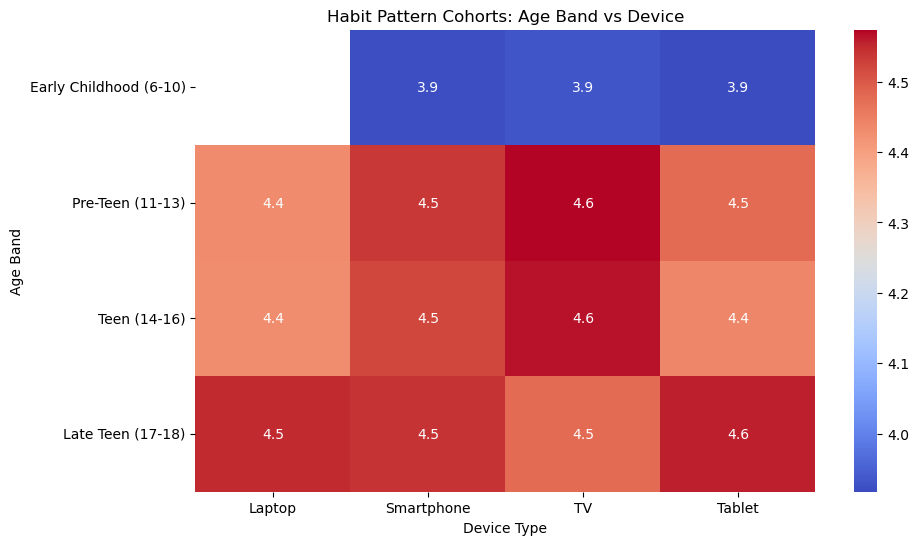

In [68]:
cohort_pattern = df.groupby(['Age_Band','Primary_Device'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(cohort_pattern, annot=True, cmap='coolwarm')

plt.title("Habit Pattern Cohorts: Age Band vs Device")
plt.xlabel("Device Type")
plt.ylabel("Age Band")
plt.show()